In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [ ]:
ames = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = ames.frame.copy()

print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
target_col = "SalePrice"

X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (876, 80)
Validation: (292, 80)
Test: (292, 80)


In [ ]:
missing_ratio = X_train.isnull().mean().sort_values(ascending=False)

missing_ratio.head(15)

,0
PoolQC,0.995434
MiscFeature,0.957763
Alley,0.933790
Fence,0.809361
FireplaceQu,0.479452
LotFrontage,0.190639
GarageType,0.052511
GarageYrBlt,0.052511
GarageQual,0.052511
GarageFinish,0.052511


In [ ]:
drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]

In [ ]:
cat_none_cols = [
    "FireplaceQu",
    "GarageType",
    "GarageQual",
    "GarageFinish",
    "GarageCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtFinType1",
    "BsmtCond"
]

In [ ]:
num_median_cols = ["LotFrontage", "GarageYrBlt"]

In [ ]:
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

In [ ]:
X_train_clean = X_train_clean.drop(columns=drop_cols)
X_val_clean = X_val_clean.drop(columns=drop_cols)
X_test_clean = X_test_clean.drop(columns=drop_cols)

In [ ]:
for col in cat_none_cols:
    X_train_clean[col] = X_train_clean[col].fillna("None")
    X_val_clean[col] = X_val_clean[col].fillna("None")
    X_test_clean[col] = X_test_clean[col].fillna("None")

In [ ]:
for col in num_median_cols:
    median_val = X_train[col].median()

    X_train_clean[col] = X_train_clean[col].fillna(median_val)
    X_val_clean[col] = X_val_clean[col].fillna(median_val)
    X_test_clean[col] = X_test_clean[col].fillna(median_val)

In [ ]:
X_train_clean.isnull().sum().sort_values(ascending=False).head()

,0
BsmtFinType2,22
MasVnrType,2
MasVnrArea,2
Electrical,1
LotArea,0


In [ ]:
X_train_clean["BsmtFinType2"] = X_train_clean["BsmtFinType2"].fillna("None")
X_val_clean["BsmtFinType2"] = X_val_clean["BsmtFinType2"].fillna("None")
X_test_clean["BsmtFinType2"] = X_test_clean["BsmtFinType2"].fillna("None")

In [ ]:
X_train_clean["MasVnrType"] = X_train_clean["MasVnrType"].fillna("None")
X_val_clean["MasVnrType"] = X_val_clean["MasVnrType"].fillna("None")
X_test_clean["MasVnrType"] = X_test_clean["MasVnrType"].fillna("None")

In [ ]:
X_train_clean["MasVnrArea"] = X_train_clean["MasVnrArea"].fillna(0)
X_val_clean["MasVnrArea"] = X_val_clean["MasVnrArea"].fillna(0)
X_test_clean["MasVnrArea"] = X_test_clean["MasVnrArea"].fillna(0)

In [ ]:
mode_val = X_train_clean["Electrical"].mode()[0]

X_train_clean["Electrical"] = X_train_clean["Electrical"].fillna(mode_val)
X_val_clean["Electrical"] = X_val_clean["Electrical"].fillna(mode_val)
X_test_clean["Electrical"] = X_test_clean["Electrical"].fillna(mode_val)

In [ ]:
X_train_clean.isnull().sum().sum()

np.int64(0)

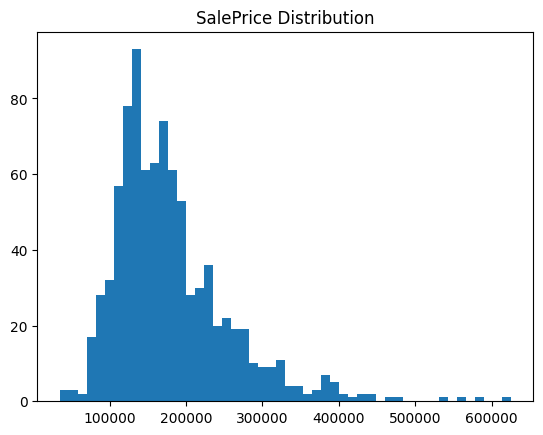

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_train, bins=50)
plt.title("SalePrice Distribution")
plt.show()

In [ ]:
numeric_df = X_train_clean.select_dtypes(include=["int64", "float64"])

corr = numeric_df.join(y_train).corr()

corr["SalePrice"].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.781592
GrLivArea,0.665931
GarageCars,0.636458
GarageArea,0.615012
TotalBsmtSF,0.577081
1stFlrSF,0.574447
FullBath,0.535206
YearRemodAdd,0.519089
TotRmsAbvGrd,0.511087


In [ ]:
top_features = corr["SalePrice"].sort_values(ascending=False).index[1:4]

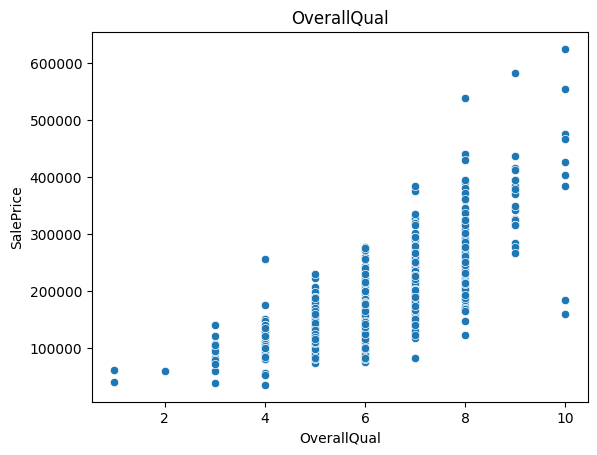

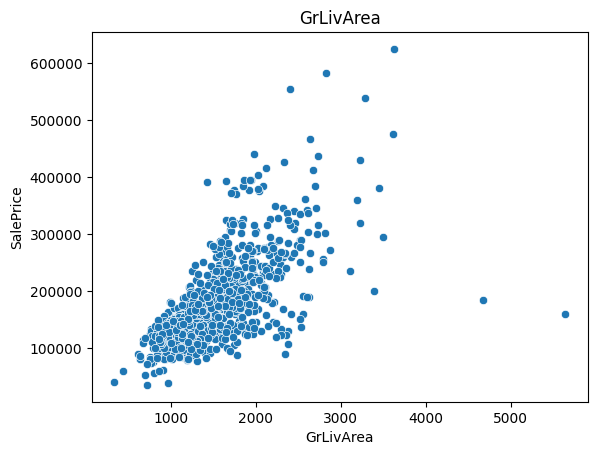

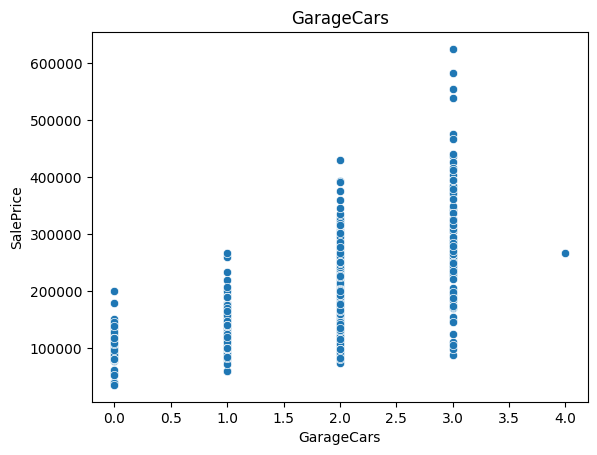

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in top_features:
    sns.scatterplot(x=X_train_clean[col], y=y_train)
    plt.title(col)
    plt.show()

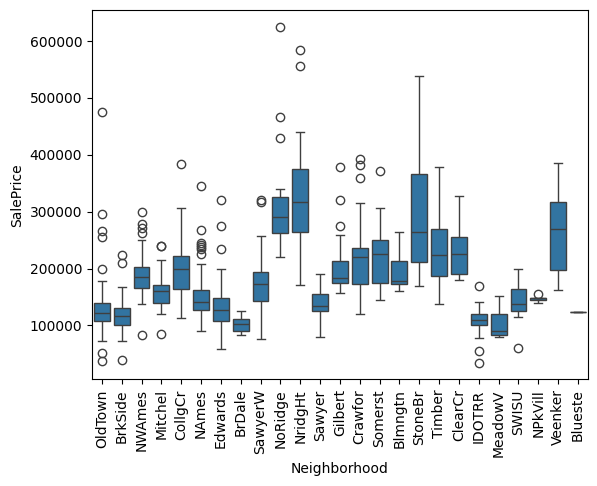

In [ ]:
sns.boxplot(x=X_train_clean["Neighborhood"], y=y_train)
plt.xticks(rotation=90)
plt.show()

In [ ]:
selected_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearRemodAdd",
    "TotRmsAbvGrd",
    "Neighborhood",
    "KitchenQual",
    "ExterQual"
]

In [ ]:
X_train_final = X_train_clean[selected_features]
X_val_final = X_val_clean[selected_features]
X_test_final = X_test_clean[selected_features]

In [ ]:
mask = X_train_final["GrLivArea"] < 4500

X_train_final = X_train_final[mask]
y_train = y_train[mask]

Based on correlation analysis and visual inspection, we selected the most influential features for modeling. Outliers in GrLivArea were also removed to improve model stability.

In [ ]:
num_cols = [
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearRemodAdd",
    "TotRmsAbvGrd"
]

In [ ]:
ordinal_cols = [
    "OverallQual",
    "KitchenQual",
    "ExterQual"
]

In [ ]:
nominal_cols = ["Neighborhood"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

In [ ]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [ ]:
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(categories=[quality_order] * len(ordinal_cols)))
])

In [ ]:
nominal_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("nom", nominal_pipeline, nominal_cols)
])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [ ]:
ordinal_cols = [
    "KitchenQual",
    "ExterQual"
]

In [ ]:
num_cols = [
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearRemodAdd",
    "TotRmsAbvGrd",
    "OverallQual"
]

In [ ]:
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(categories=[quality_order, quality_order]))
])

In [ ]:
ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

In [ ]:
X_train_final.dtypes

,0
OverallQual,int64
GrLivArea,int64
GarageCars,int64
TotalBsmtSF,int64
FullBath,int64
YearRemodAdd,int64
TotRmsAbvGrd,int64
Neighborhood,object
KitchenQual,object
ExterQual,object


In [ ]:
print("num_cols:", num_cols)
print(X_train_final[num_cols].dtypes)

print("\nordinal_cols:", ordinal_cols)
print(X_train_final[ordinal_cols].dtypes)

print("\nnominal_cols:", nominal_cols)
print(X_train_final[nominal_cols].dtypes)

num_cols: ['GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearRemodAdd', 'TotRmsAbvGrd', 'OverallQual']
GrLivArea       int64
GarageCars      int64
TotalBsmtSF     int64
FullBath        int64
YearRemodAdd    int64
TotRmsAbvGrd    int64
OverallQual     int64
dtype: object

ordinal_cols: ['KitchenQual', 'ExterQual']
KitchenQual    object
ExterQual      object
dtype: object

nominal_cols: ['Neighborhood']
Neighborhood    object
dtype: object


In [ ]:
for col in ordinal_cols:
    print(f"\n--- {col} ---")
    print(X_train_final[col].dropna().unique())


--- KitchenQual ---
['Ex' 'TA' 'Gd' 'Fa']

--- ExterQual ---
['TA' 'Gd' 'Ex' 'Fa']


In [ ]:
num_cols = [
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearRemodAdd",
    "TotRmsAbvGrd",
    "OverallQual",
]

ordinal_cols = [
    "KitchenQual",
    "ExterQual",
]

nominal_cols = [
    "Neighborhood",
]

In [ ]:
print("Overlap num/ord:", set(num_cols) & set(ordinal_cols))
print("Overlap num/nom:", set(num_cols) & set(nominal_cols))
print("Overlap ord/nom:", set(ordinal_cols) & set(nominal_cols))

Overlap num/ord: set()
Overlap num/nom: set()
Overlap ord/nom: set()


In [ ]:
for col in ordinal_cols:
    X_train_final[col] = X_train_final[col].astype(str)
    X_val_final[col] = X_val_final[col].astype(str)
    X_test_final[col] = X_test_final[col].astype(str)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(
        categories=[
            ["Po", "Fa", "TA", "Gd", "Ex"],
            ["Po", "Fa", "TA", "Gd", "Ex"],
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(
        categories=[
            ["Po", "Fa", "TA", "Gd", "Ex"],
            ["Po", "Fa", "TA", "Gd", "Ex"],
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("nom", nominal_pipeline, nominal_cols),
])

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train_final, y_train)
print(type(X_train_transformed))
print(X_train_transformed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(874, 34)


In [ ]:
lr_pipeline.fit(X_train_final, y_train)
rf_pipeline.fit(X_train_final, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['GrLivArea', 'GarageCars',
                                                   'TotalBsmtSF', 'FullBath',
                                                   'YearRemodAdd',
                                                   'TotRmsAbvGrd',
                                                   'OverallQual']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['KitchenQual', 'ExterQual']),
                                                 ('nom',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def evaluate(model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    return rmse, r2, mae

In [ ]:
lr_rmse, lr_r2, lr_mae = evaluate(lr_pipeline, X_val_final, y_val)
rf_rmse, rf_r2, rf_mae = evaluate(rf_pipeline, X_val_final, y_val)

print("Linear Regression:", lr_rmse, lr_r2, lr_mae)
print("Random Forest:", rf_rmse, rf_r2, rf_mae)

Linear Regression: 38508.35307200127 0.8425340875528549 23188.514424058205
Random Forest: 33519.52681585857 0.8806912151910129 21151.035665198957


In [ ]:
rf_rmse_test, rf_r2_test, rf_mae_test = evaluate(rf_pipeline, X_test_final, y_test)

print("Random Forest TEST:", rf_rmse_test, rf_r2_test, rf_mae_test)

Random Forest TEST: 23567.63046128354 0.8864281618896224 16898.699190965428


In [ ]:
import joblib

joblib.dump(rf_pipeline, "best_model.pkl")